# Import Libraries

In [174]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter

# Load Dataset

In [175]:
df = pd.read_csv("../data/jobs.csv")

### Check dimensions

In [176]:
df.shape

(30000, 11)

### View the Dataset

In [177]:
df.head()

,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
0,9be62c49a0b7ebe982a4af1edaa7bc5f,2019-07-05 01:46:07 +0000,Digital Media Planner,Not Disclosed by Recruiter,5 - 10 yrs,Media Planning| Digital Media,Advertising,Mumbai,"Marketing , Advertising , MR , PR , Media Plan...","Advertising, PR, MR, Event Management",Media Planning Executive/Manager
1,3c52d436e39f596b22519da2612f6a56,2019-07-06 08:04:50 +0000,Online Bidding Executive,Not Disclosed by Recruiter,2 - 5 yrs,pre sales| closing| software knowledge| clien...,Retail Sales,"Pune,Pune","Sales , Retail , Business Development","IT-Software, Software Services",Sales Executive/Officer
2,ffad8a2396c60be2bf6d0e2ff47c58d4,2019-08-05 15:50:44 +0000,Trainee Research/ Research Executive- Hi- Tec...,Not Disclosed by Recruiter,0 - 1 yrs,Computer science| Fabrication| Quality check|...,R&D,Gurgaon,"Engineering Design , R&D","Recruitment, Staffing",R&D Executive
3,7b921f51b5c2fb862b4a5f7a54c37f75,2019-08-05 15:31:56 +0000,Technical Support,"2,00,000 - 4,00,000 PA.",0 - 5 yrs,Technical Support,Admin/Maintenance/Security/Datawarehousing,Mumbai,"IT Software - Application Programming , Mainte...","IT-Software, Software Services",Technical Support Engineer
4,2d8b7d44e138a54d5dc841163138de50,2019-07-05 02:48:29 +0000,Software Test Engineer -hyderabad,Not Disclosed by Recruiter,2 - 5 yrs,manual testing| test engineering| test cases|...,Programming & Design,Hyderabad,IT Software - QA & Testing,"IT-Software, Software Services",Testing Engineer


In [178]:
df.tail()

,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
29995,3510f2146b514f112eaa9706a16b3900,2019-07-06 21:12:51 +0000,MTS-Software-Engineer,Not Disclosed by Recruiter,9 - 12 yrs,Graphics| C++| USB| Project management| SOC| ...,Programming & Design,Bengaluru,"IT Software - Embedded , EDA , VLSI , ASIC , C...","Semiconductors, Electronics",Software Developer
29996,4af8c56f5b4c535b1974065003f2d548,2019-08-05 23:55:08 +0000,Client Relationship Manager,Not Disclosed by Recruiter,1 - 5 yrs,Service delivery| LMS| CRE| Integration servi...,Operations,Chennai,"ITES , BPO , KPO , LPO , Customer Service , Op...","Education, Teaching, Training",Operations Manager
29997,43d5b806b26ed99d3ebfc8f366b4cdd1,2019-08-05 09:41:29 +0000,Assoc. Prof.- CS,Not Disclosed by Recruiter,4 - 6 yrs,Counselor| Mentor| Trainer| Advisor| Teaching,University Level,Howrah,"Teaching , Education , Training , Counselling","Education, Teaching, Training",Lecturer/Professor
29998,8bc87d14cf56564f16b6d4bae80180be,2019-08-06 01:44:55 +0000,Application/Cyber Security Specialist-Pune,Not Disclosed by Recruiter,5 - 10 yrs,Security Analysis| Software Development Life ...,Programming & Design,Pune,"IT Software - Application Programming , Mainte...","IT-Software, Software Services",Software Developer
29999,9c7045d111814a6f39fe461eab2b0bf8,2019-07-06 22:24:55 +0000,Press Release Writer - SEO,Not Disclosed by Recruiter,2 - 7 yrs,Press release| Public relations| Publishing| ...,Online/Digital Marketing,Bengaluru,"Marketing , Advertising , MR , PR , Media Plan...","IT-Software, Software Services",Search Engine Optimisation /SEO Specialist


In [179]:
df.sample(5)

,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
26961,9393c74c867405ae18844ee52952272e,2019-08-04 01:56:48 +0000,PAN card Documents Verification,Not Disclosed by Recruiter,0 - 0 yrs,documents scanning,NaN,Kolkata,Other,Other,Other
4265,5c2c700035a9c6cd40f757e38bf547f0,2019-07-04 16:19:11 +0000,Adeeba Group hiring Customer Support Exec Spo...,Not Disclosed by Recruiter,0 - 3 yrs,Outbound| Group| Sales| Spot| Inbound calls| ...,Voice,Kolkata,"ITES , BPO , KPO , LPO , Customer Service , Op...","IT-Software, Software Services",Associate/Senior Associate -(NonTechnical)
28061,585dcf9101dcf0fc454f806695dec38e,2019-08-06 08:43:32 +0000,Sales Recruiter,Not Disclosed by Recruiter,7 - 10 yrs,Relationship management| sales hiring| Sales ...,HR/ Recruitment / IR,Bengaluru,"HR , Recruitment , Administration , IR","IT-Software, Software Services",Recruitment Executive
2413,c9512f021290e68bab2d9f18fac2670d,2019-07-04 14:51:59 +0000,SR. EXEC / AM HR For Mumbai_ NAVI Mumbai,Fixed Salary+incentives+ Bonus,3 - 6 yrs,HR| Recruitment| Employee Engagement| Hiring|...,HR/ Recruitment / IR,"Mumbai,Mumbai Suburbs,Navi Mumbai","HR , Recruitment , Administration , IR","Banking, Financial Services, Broking",Recruitment Manager
20496,cf050f5580e13613d7aa7ad84335d9fc,2019-07-05 04:56:08 +0000,Sales Executive / Merchandiser,Not Disclosed by Recruiter,1 - 5 yrs,new business development| modern retail| prom...,Retail Sales,"Mumbai,Bengaluru,Pune","Sales , Retail , Business Development","FMCG, Foods, Beverage",Merchandiser


## Check Column Names

In [180]:
df.columns

Index(['Uniq Id', 'Crawl Timestamp', 'Job Title', 'Job Salary',
       'Job Experience Required', 'Key Skills', 'Role Category', 'Location',
       'Functional Area', 'Industry', 'Role'],
      dtype='object')

# Data Understanding

## Dataset Info

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Uniq Id                  30000 non-null  object
 1   Crawl Timestamp          30000 non-null  object
 2   Job Title                29425 non-null  object
 3   Job Salary               29950 non-null  object
 4   Job Experience Required  29427 non-null  object
 5   Key Skills               28729 non-null  object
 6   Role Category            27695 non-null  object
 7   Location                 29423 non-null  object
 8   Functional Area          29427 non-null  object
 9   Industry                 29427 non-null  object
 10  Role                     29099 non-null  object
dtypes: object(11)
memory usage: 2.5+ MB


## Missing Value Analysis

In [182]:
df.isnull().sum()

Uniq Id                       0
Crawl Timestamp               0
Job Title                   575
Job Salary                   50
Job Experience Required     573
Key Skills                 1271
Role Category              2305
Location                    577
Functional Area             573
Industry                    573
Role                        901
dtype: int64

### calculate percentages

In [183]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

Role Category              7.683333
Key Skills                 4.236667
Role                       3.003333
Location                   1.923333
Job Title                  1.916667
Functional Area            1.910000
Job Experience Required    1.910000
Industry                   1.910000
Job Salary                 0.166667
Crawl Timestamp            0.000000
Uniq Id                    0.000000
dtype: float64

## Duplicate Records Analysis

In [184]:
df.isnull().sum()

Uniq Id                       0
Crawl Timestamp               0
Job Title                   575
Job Salary                   50
Job Experience Required     573
Key Skills                 1271
Role Category              2305
Location                    577
Functional Area             573
Industry                    573
Role                        901
dtype: int64

### duplicate job records based on useful columns

In [185]:
df.duplicated(
    subset=["Job Title", "Key Skills"]
).sum()

np.int64(471)

## Inspect Key Skills

In [186]:
df["Key Skills"].head(20)

0                         Media Planning| Digital Media
1      pre sales| closing| software knowledge| clien...
2      Computer science| Fabrication| Quality check|...
3                                     Technical Support
4      manual testing| test engineering| test cases|...
5      adobe experience manager| digital| digital ma...
6      channel partners| real estate| negotiation| p...
7      TFS| Azure| Git| VSTS| Docker| DynaTrace| Spl...
8                                                   Bde
9      technical support| support services| applicat...
10                   secretary| executive assistant| ea
11     website| web analytics| xml| link building| g...
12     operations| workflow| tat| monitoring| mts| e...
13                                  Oracle IDAM|OIM|OAM
14     digital marketing| seo| social media marketin...
15     instrumentation engineering| electrical engin...
16     Help Desk| Customer Service| customer relatio...
17     Report Generation| Policies| analytical| 

## Clean the Dataset

### make a copy

In [187]:
clean_df = df.copy()

### Removing completely empty rows

In [188]:
clean_df = clean_df.dropna(
    how="all"
)

### Removing the records where Key Skills is missing

In [189]:
clean_df = clean_df.dropna(
    subset=["Key Skills"]
)

### removing empty strings

In [190]:
clean_df = clean_df[
    clean_df["Key Skills"].astype(str).str.strip() != ""
]

## Clean Text

In [191]:
def clean_text(text):
    text = str(text)
    
    text = text.lower()
    
    text = re.sub(
        r"\s+",
        " ",
        text
    )
    
    text = text.strip()
    
    return text

In [192]:
clean_df["clean_skills"] = (
    clean_df["Key Skills"]
    .apply(clean_text)
)

### Removing Duplicate Jobs

In [193]:
clean_df = clean_df.drop_duplicates(
    subset=["Job Title", "clean_skills"]
)

In [194]:
clean_df.shape

(28498, 12)

### Saving Clean Dataset

In [195]:
clean_df.to_csv(
    "../data/clean_jobs.csv",
    index=False
)

## Extract Individual Skills

In [196]:
all_skills = []

for skills in clean_df["clean_skills"]:
    
    skill_list = skills.split("|")
    
    for skill in skill_list:
        skill = skill.strip()
        
        if skill:
            all_skills.append(skill)

In [197]:
all_skills

['media planning',
 'digital media',
 'pre sales',
 'closing',
 'software knowledge',
 'clients',
 'requirements',
 'negotiating',
 'client',
 'online bidding',
 'good communication',
 'technology',
 'computer science',
 'fabrication',
 'quality check',
 'intellectual property',
 'electronics',
 'support services',
 'research',
 'management',
 'human resource management',
 'research executive',
 'technical support',
 'manual testing',
 'test engineering',
 'test cases',
 'web testing',
 'web technologies',
 'adobe experience manager',
 'digital',
 'digital marketing',
 'adobe analytics',
 'data analytics',
 'aem',
 'adobe',
 'sitecatalyst',
 'channel partners',
 'real estate',
 'negotiation',
 'property',
 'residential sales',
 'tfs',
 'azure',
 'git',
 'vsts',
 'docker',
 'dynatrace',
 'splunk',
 'aws',
 'bde',
 'technical support',
 'support services',
 'application support',
 'communication skills',
 'voice based process',
 'semi voice',
 'semi voice process',
 'secretary',
 'execut

In [198]:
len(all_skills)

246371

### Create Skill Frequency Table

In [199]:
skill_counts = Counter(all_skills)

#### Top 20

In [200]:
skill_counts.most_common(20)

[('sales', 3168),
 ('manager', 2888),
 ('developer', 2458),
 ('javascript', 2254),
 ('java', 1733),
 ('sql', 1558),
 ('html', 1535),
 ('executive', 1533),
 ('customer service', 1327),
 ('hr', 1243),
 ('python', 1216),
 ('engineer', 1201),
 ('software', 1188),
 ('recruitment', 1100),
 ('jquery', 1088),
 ('marketing', 1055),
 ('business development', 1053),
 ('technical support', 1028),
 ('management', 950),
 ('development', 946)]

#### Convert to DataFrame

In [201]:
top_skills = pd.DataFrame(
    skill_counts.most_common(20),
    columns=["Skill", "Count"]
)

top_skills

,Skill,Count
0,sales,3168
1,manager,2888
2,developer,2458
3,javascript,2254
4,java,1733
5,sql,1558
6,html,1535
7,executive,1533
8,customer service,1327
9,hr,1243


### Visualizing Top Skills

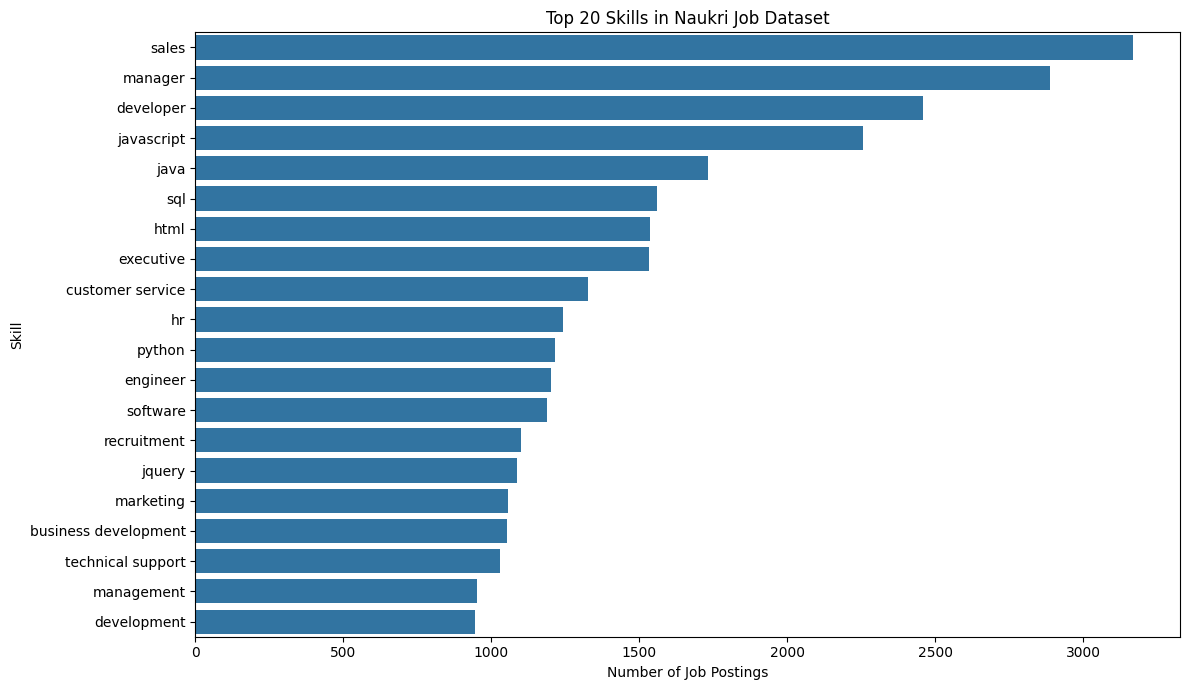

In [202]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_skills,
    x="Count",
    y="Skill"
)

plt.title("Top 20 Skills in Naukri Job Dataset")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

### Number of Skills Per Job

In [203]:
clean_df["skill_count"] = (
    clean_df["clean_skills"]
    .apply(lambda x: len(x.split("|")))
)

In [204]:
clean_df["skill_count"].describe()

count    28498.000000
mean         8.645694
std          9.148292
min          1.000000
25%          5.000000
50%          8.000000
75%         10.000000
max        185.000000
Name: skill_count, dtype: float64

#### Plot

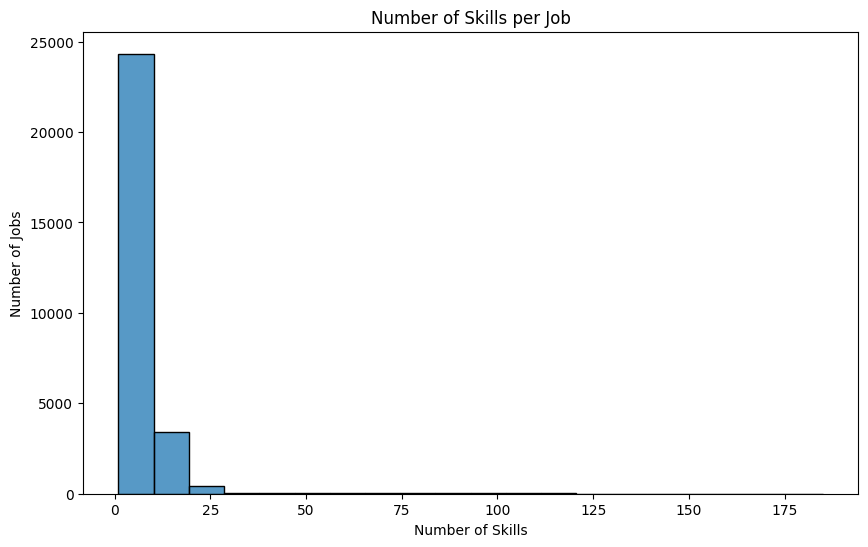

In [205]:
plt.figure(figsize=(10, 6))

sns.histplot(
    clean_df["skill_count"],
    bins=20
)

plt.title("Number of Skills per Job")
plt.xlabel("Number of Skills")
plt.ylabel("Number of Jobs")

plt.show()

### Most Common Job Titles

In [206]:
clean_df["Job Title"].value_counts().head(20)

Job Title
 Business Development Executive    115
 PHP Developer                     115
 Sales Executive                   102
 Business Development Manager       94
 Graphic Designer                   81
 Software Engineer                  76
 Java Developer                     75
 Android Developer                  70
 Sales Manager                      70
 Content Writer                     69
 Senior Software Engineer           61
 Business Analyst                   61
 Marketing Executive                59
 Dot Net Developer                  57
Job Description                     57
 Web Designer                       54
 Software Developer                 46
 Project Manager                    43
 Accounts Executive                 37
 HR Executive                       37
Name: count, dtype: int64

#### Plot

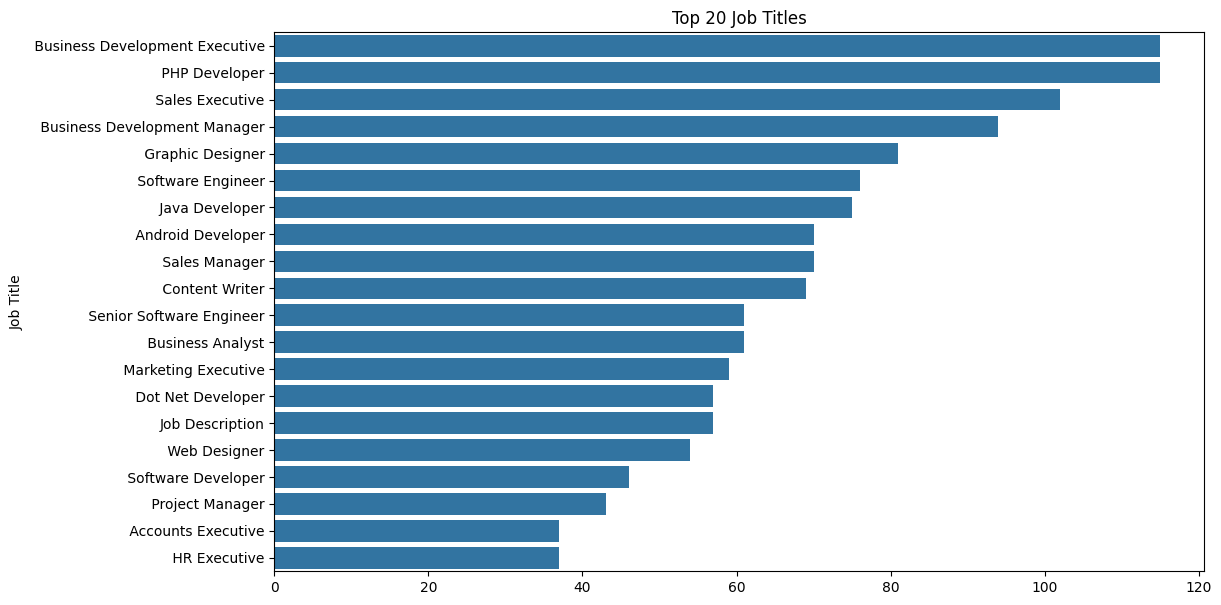

In [207]:
top_jobs = (
    clean_df["Job Title"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top 20 Job Titles")

plt.show()

### NLP Skill Normalization

In [208]:
def normalize_skill(skill):
    
    skill = str(skill).lower()
    
    skill = skill.strip()
    
    skill = re.sub(
        r"\s+",
        " ",
        skill
    )
    
    return skill

In [209]:
normalized_skills = [
    normalize_skill(skill)
    for skill in all_skills
]

### Build Final Skill Dictionary

In [210]:
skill_counts = Counter(normalized_skills)

#### Create a Dictionary

In [211]:
skill_dictionary = set(
    skill_counts.keys()
)

In [212]:
len(skill_dictionary)

14655

In [213]:
list(skill_dictionary)[:50]

['reliability prediction',
 'counter',
 'protools',
 'uk gaap',
 'sql server 2005',
 'doctors',
 'assistant professor- pharmacy',
 'mac os',
 'orm',
 'mortgage underwriting',
 'senior us it recruiter',
 'pci',
 'gold loan executive',
 'google adwordsoffice skills',
 'sacs',
 'associate editor',
 'vrops',
 'category',
 'employee referral',
 'hr coordinator',
 'record keeping',
 'retail selling',
 'international law',
 'ai programmer',
 'documentation',
 'products',
 'it trainer',
 'recruiter',
 'punctual',
 'jax - ws',
 'qtp',
 'catalogues',
 'websphere portal',
 'technical manager',
 'mbd',
 'term loans',
 'interview scheduling',
 'nav',
 'rbs',
 'bpo fresher',
 'atm',
 'doctor',
 'site lead',
 'z - wave',
 'sql database administrator',
 'human resource manager',
 'statutory compliances',
 'motor insurance',
 'inside',
 'system architect']

### Removing Bad/Generic Skills

In [214]:
generic_words = {
    "experience",
    "knowledge",
    "work",
    "working",
    "candidate",
    "good",
    "skills",
    "team",
    "job",
    "role",
    "required",
    "responsible"
}

In [215]:
skill_dictionary = {
    skill
    for skill in skill_dictionary
    if skill not in generic_words
}

In [216]:
skill_dictionary 

{'reliability prediction',
 'counter',
 'protools',
 'uk gaap',
 'sql server 2005',
 'doctors',
 'assistant professor- pharmacy',
 'senior us it recruiter',
 'mac os',
 'orm',
 'mortgage underwriting',
 'pci',
 'gold loan executive',
 'google adwordsoffice skills',
 'sacs',
 'associate editor',
 'vrops',
 'category',
 'employee referral',
 'hr coordinator',
 'record keeping',
 'retail selling',
 'international law',
 'ai programmer',
 'documentation',
 'products',
 'it trainer',
 'recruiter',
 'punctual',
 'jax - ws',
 'qtp',
 'catalogues',
 'websphere portal',
 'technical manager',
 'mbd',
 'term loans',
 'interview scheduling',
 'nav',
 'rbs',
 'bpo fresher',
 'atm',
 'doctor',
 'site lead',
 'z - wave',
 'human resource manager',
 'sql database administrator',
 'statutory compliances',
 'motor insurance',
 'inside',
 'system architect',
 'master data',
 'derma',
 'google analytics',
 'medical microbiology',
 'aaa / dra',
 'sap logistics',
 'page',
 'vera',
 'jee',
 'member technical

### Named Entity Recognition

#### Install / Load spaCy

In [217]:
import sys

!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 8.7 MB/s eta 0:00:02
     --------- ------------------------------ 2.9/12.8 MB 7.4 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 8.9 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 10.2 MB/s eta 0:00:01
     ----------------------------------- --- 11.5/12.8 MB 10.9 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 11.1 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 8.3 MB/s  0:00:01
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [218]:
import spacy

print(spacy.__version__)
print(spacy.util.is_package("en_core_web_sm"))

3.8.15
True


#### Load the English pipeline

In [219]:
import spacy

nlp = spacy.blank("en")

#### Adding EntityRuler

In [220]:
ruler = nlp.add_pipe("entity_ruler")

### Creating Skill Patterns

In [221]:
patterns = [
    {
        "label": "SKILL",
        "pattern": skill
    }
    for skill in clean_skill_dictionary
]

In [222]:
patterns = []

for skill in clean_skill_dictionary:
    
    words = skill.split()
    
    pattern = [
        {"LOWER": word}
        for word in words
    ]
    
    patterns.append({
        "label": "SKILL",
        "pattern": pattern
    })

In [223]:
len(patterns)

14437

### Adding Patterns

In [224]:
ruler.add_patterns(patterns)

### Testing  the NER

In [225]:
text = """
We are looking for a Python Developer
with experience in Django, SQL, AWS,
Docker and Machine Learning.
"""

In [226]:
doc = nlp(text)

#### Extracting entities

In [227]:
for ent in doc.ents:
    print(ent.text, "→", ent.label_)

Python Developer → SKILL
Django → SKILL
SQL → SKILL
AWS → SKILL
Docker → SKILL
Machine Learning → SKILL


#### Testing with another text

In [228]:
text1 = """
Data Scientist required with Python,
Pandas, NumPy, SQL, Machine Learning
and TensorFlow.
"""

doc = nlp(text1)

for ent in doc.ents:
    print(ent.text, "→", ent.label_)

Data Scientist → SKILL
Python → SKILL
Pandas → SKILL
SQL → SKILL
Machine Learning → SKILL


### Saving the Skill Dictionary

In [229]:
for word in ["and", "for", "developer", "aws", "docker", "sql"]:
    print(word, word in skill_dictionary)

and True
for True
developer True
aws True
docker True
sql True


In [230]:
noise_words = {
    "looking",
    "look",
    "candidate",
    "candidates",
    "experience",
    "required",
    "requirements",
    "responsible",
    "responsibilities",
    "knowledge",
    "working",
    "work",
    "job",
    "role",
    "skills",
    "skill",
    "good",
    "ability",
    "abilities",
    "must",
    "should",
    "need",
    "needed",
    "prefer",
    "preferred",
    "strong",
    "excellent",
    "understanding",
    "familiar",
    "familiarity"
}

In [231]:
skill_dictionary = {
    skill
    for skill in skill_dictionary
    if skill not in noise_words
}

In [232]:
generic_single_words = {
    "and",
    "or",
    "for",
    "with",
    "the",
    "of",
    "in",
    "to",
    "on",
    "a",
    "an",
    "is",
    "are",
    "be",
    "as",
    "at",
    "by",
    "from",
    "using",
    "use",
    "work",
    "working",
    "job",
    "role",
    "candidate",
    "candidates",
    "developer",
    "developers",
    "experience",
    "knowledge",
    "skills",
    "skill",
    "required",
    "requirements",
    "responsible",
    "responsibilities",
    "good",
    "team",
    "teams",
    "looking"
}

In [233]:
clean_skill_dictionary = {
    skill
    for skill in clean_skill_dictionary
    if skill not in generic_single_words
}

In [234]:
for word in [
    "and",
    "for",
    "developer",
    "looking",
    "looking for",
    "aws",
    "docker",
    "sql",
    "python"
]:
    
    print(
        word,
        "→",
        word in clean_skill_dictionary
    )

and → False
for → False
developer → False
looking → False
looking for → False
aws → True
docker → True
sql → True
python → True


In [235]:
for word in ["and", "for", "developer"]:
    print(word, word in skill_dictionary)

and True
for True
developer True


In [236]:
import json

with open(
    "../models/skill_dictionary.json",
    "w",
    encoding="utf-8"
) as f:
    
    json.dump(
        sorted(skill_dictionary),
        f,
        indent=2
    )

### Saving the NER Pipeline

In [237]:
nlp.to_disk(
    "../models/skill_ner_model"
)

### Load the Saved Model

In [238]:
skill_nlp = spacy.load(
    "../models/skill_ner_model"
)

In [239]:
doc = skill_nlp(
    "Python developer with AWS, Docker and SQL experience"
)

In [240]:
for ent in doc.ents:
    print(ent.text, ent.label_)

Python developer SKILL
AWS SKILL
Docker SKILL
SQL SKILL


#### Build an Extraction Function

In [241]:
def extract_skills(text, nlp_model):
    
    doc = nlp_model(text)
    
    skills = []
    
    for ent in doc.ents:
        
        if ent.label_ == "SKILL":
            skills.append(ent.text)
    
    return skills

#### Testing

In [242]:
text = """
Looking for a Data Scientist with Python,
SQL, Machine Learning, TensorFlow,
Pandas and AWS.
"""

extract_skills(
    text,
    skill_nlp
)

['Data Scientist', 'Python', 'SQL', 'Machine Learning', 'Pandas', 'AWS']

#### Adding Evaluation

In [243]:
test_examples = [
    {
        "text": "Python developer with AWS and Docker",
        "skills": ["Python", "AWS", "Docker"]
    },
    {
        "text": "Looking for Java Spring Boot developer with MySQL",
        "skills": ["Java", "Spring Boot", "MySQL"]
    },
    {
        "text": "Data scientist with Python, Pandas and Machine Learning",
        "skills": ["Python", "Pandas", "Machine Learning"]
    }
]

### Creating train_ner.py